In [1]:
##### importing custom modules from the projects folder
import sys
from pathlib import Path
# Start at current working directory
current = Path.cwd()
# Walk up the tree until config.py is found or root is reached
for parent in [current] + list(current.parents):
    config_path = parent / "config.py"
    if config_path.exists():
        sys.path.append(str(parent))
        import config # <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<< 
        break
else:
    raise FileNotFoundError("config.py not found in any parent directories")

import scripts.models.nbaPlayerStatModeling as nbaModel
import scripts.functions.NBAhelperfunctions as hf
import pandas as pd
import numpy as np
pd.set_option('display.max_rows', None)  # Show all rows
pd.set_option('display.max_columns', 20)  # Show all columns
pd.set_option('display.max_colwidth', None)  # Show full column width

In [ ]:
# udpate player database table
#hf.add_new_players_to_db(
#    refresh_ext_player_table = False, 
#    season= 2026
#)

In [18]:
nba = nbaModel.playerStatModel(
        day_offset = 0, 
        season = '2025-26', 
        perMode = 'PerGame',
        num_simulations = 200000
)
nba.get_teams_playing(
    url = 'https://cdn.nba.com/static/json/liveData/scoreboard/todaysScoreboard_00.json',
    use_api = False  
)
nba.get_teams_data(
    base_url = 'https://stats.nba.com/stats/leaguedashteamstats?Conference=&DateFrom=&DateTo=&Division=&GameScope=&GameSegment=&Height=&ISTRound=&LastNGames=0&LeagueID=00&Location=&MeasureType={stattype}&Month=0&OpponentTeamID=0&Outcome=&PORound=0&PaceAdjust=N&PerMode=PerGame&Period=0&PlayerExperience=&PlayerPosition=&PlusMinus=N&Rank=N&Season={sid}&SeasonSegment=&SeasonType=Regular%20Season&ShotClockRange=&StarterBench=&TeamID=0&TwoWay=0&VsConference=&VsDivision='
)

nba.get_players_playing(
    url_base_nba_player_stat = 'https://stats.nba.com/stats/leaguedashplayerstats?College=&Conference=&Country=&DateFrom=&DateTo=&Division=&DraftPick=&DraftYear=&GameScope=&GameSegment=&Height=&LastNGames=0&LeagueID=00&Location=&MeasureType=Base&Month=0&OpponentTeamID=0&Outcome=&PORound=0&PaceAdjust=N&PerMode={per}&Period=0&PlayerExperience=&PlayerPosition=&PlusMinus=N&Rank=N&Season={sid}&SeasonSegment=&SeasonType=Regular+Season&ShotClockRange=&StarterBench=&TeamID={tid}&TwoWay=0&VsConference=&VsDivision=&Weight=',
    minute_cutoff = 10,
    season = '2026',
    pull_players_from_nbaapi = False
)

nba.get_props()

nba.get_player_home_adv(
    use_default=False,
    sleep_time = 3
)
#nba.df_players = nba.df_players[(nba.df_players['FG3A'] > 0) & (nba.df_players['FTA'] > 0)]
df_copy = nba.df_players.copy()

5  games today...
97 players returned from 10 teams, out of a total 10
754 prop bets for 70 players...


In [20]:
nba.df_players = df_copy.copy()
nba.model_expected_minutes()
nba.calculate_expected_stats()


In [24]:
nba.df_players

,PLAYER_ID,PLAYER_NAME,TEAM_ID,TEAM_ABBREVIATION,MIN,FGM,FGA,FG3M,FG3A,FTM,...,expFGM_FTM,expFGA_FTA,expPts,expStl,expBlk,expPra,expPr,expPa,expRa,expSb
0,6477,Jonas Valanciunas,1610612743,DEN,12.0,4.0,5.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,6478,Nikola Vucevic,1610612741,CHI,33.0,11.0,18.0,4.0,6.0,2.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,2528210,Tim Hardaway Jr.,1610612743,DEN,22.0,4.0,8.0,2.0,5.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,2581018,Kentavious Caldwell-Pope,1610612763,MEM,27.0,2.0,7.0,2.0,6.0,5.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,2583632,Royce O'Neale,1610612756,PHX,28.5,4.0,9.5,3.0,8.5,0.5,...,5.104477,11.949116,13.225235,1.823639,0.607880,19.362401,17.773068,14.814568,6.137166,2.431519
5,3059318,Joel Embiid,1610612755,PHI,20.0,1.0,9.0,0.0,4.0,2.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,3064290,Aaron Gordon,1610612743,DEN,39.0,17.0,21.0,10.0,11.0,6.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,3112335,Nikola Jokic,1610612743,DEN,41.0,8.0,23.0,2.0,13.0,3.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,3133603,Kelly Oubre Jr.,1610612755,PHI,34.0,2.0,6.0,2.0,6.0,4.0,...,NaN,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,3135045,Grayson Allen,1610612756,PHX,32.5,5.0,12.0,3.0,8.0,2.0,...,7.192672,14.849387,16.009495,1.013133,0.607880,25.145145,18.787812,22.366828,9.135650,1.621013


In [23]:

nba.model_stats()

1
2


ValueError: p < 0, p > 1 or p contains NaNs

In [13]:
reb = nba.df_players.loc[:,['PLAYER_NAME', 'REB', 'expReb', 'reb_line', 'reb_oOdds', 'REBoOdds','REBoOdds_deci','REBoProb']].copy()
reb['stat'] = 'reb'
ast = nba.df_players.loc[:,['PLAYER_NAME', 'AST', 'expAst', 'ast_line', 'ast_oOdds', 'ASToOdds','ASToOdds_deci','ASToProb']].copy()
ast['stat'] = 'ast'
pts = nba.df_players.loc[:,['PLAYER_NAME', 'PTS', 'expPts', 'pts_line', 'pts_oOdds', 'PTSoOdds','PTSoOdds_deci','PTSoProb']].copy()
pts['stat'] = 'pts'
fg3m = nba.df_players.loc[:,['PLAYER_NAME', 'FG3M', 'expFG3M', 'threes_line', 'threes_oOdds', 'FG3MoOdds','FG3MoOdds_deci','FG3MoProb']].copy()
fg3m['stat'] = 'fg3m'
pra = nba.df_players.loc[:,['PLAYER_NAME', 'PRA', 'expPra', 'pra_line', 'pra_oOdds', 'PRAoOdds','PRAoOdds_deci','PRAoProb']].copy()
pra['stat'] = 'pra'
pr = nba.df_players.loc[:,['PLAYER_NAME', 'PR', 'expPr', 'pr_line', 'pr_oOdds', 'PRoOdds','PRoOdds_deci','PRoProb']].copy()
pr['stat'] = 'pr'
pa = nba.df_players.loc[:,['PLAYER_NAME', 'PA', 'expPa', 'pa_line', 'pa_oOdds', 'PAoOdds','PAoOdds_deci','PAoProb']].copy()
pa['stat'] = 'pa'
ra = nba.df_players.loc[:,['PLAYER_NAME', 'RA', 'expRa', 'ra_line', 'ra_oOdds', 'RAoOdds','RAoOdds_deci','RAoProb']].copy()
ra['stat'] = 'ra'
stl = nba.df_players.loc[:,['PLAYER_NAME', 'STL', 'expStl', 'stl_line', 'stl_oOdds', 'STLoOdds','STLoOdds_deci','STLoProb']].copy()
stl['stat'] = 'stl'
blk = nba.df_players.loc[:,['PLAYER_NAME', 'BLK', 'expBlk', 'blk_line', 'blk_oOdds', 'BLKoOdds','BLKoOdds_deci','BLKoProb']].copy()
blk['stat'] = 'blk'
sb = nba.df_players.loc[:,['PLAYER_NAME', 'SB', 'expSb', 'sb_line', 'sb_oOdds', 'SBoOdds','SBoOdds_deci','SBoProb']].copy()
sb['stat'] = 'sb'

pts.columns = ['PLAYER_NAME', 'act', 'exp', 'line', 'ACToOdds', 'EXPoOdds', 'EXPoOdds_deci', 'EXPoProb', 'stat'].copy()
for i in [reb, ast, fg3m, pra, pr, pa, ra, stl, blk, sb ]:
    i.columns = ['PLAYER_NAME', 'act', 'exp', 'line', 'ACToOdds', 'EXPoOdds', 'EXPoOdds_deci', 'EXPoProb', 'stat'].copy()
    pts = pd.concat([pts, i])

odds = pts[['PLAYER_NAME', 'stat', 'act', 'exp', 'line', 'ACToOdds', 'EXPoOdds', 'EXPoOdds_deci', 'EXPoProb']].copy()
odds['over_ev'] = odds['ACToOdds'] - odds['EXPoOdds']
print('all odds:', odds.shape[0])
odds_over_ev = odds[(
                    odds['over_ev']>100
                    ) & (
                    odds['act'] < odds['exp']
                    )].sort_values('over_ev', ascending=False)
print('+Ev over odds:', odds_over_ev.shape[0])
 

KeyError: "['REBoOdds', 'REBoOdds_deci', 'REBoProb'] not in index"

In [8]:
player = "Ausar"
odds[odds['PLAYER_NAME'].str.contains(player)]

,PLAYER_NAME,stat,act,exp,line,ACToOdds,EXPoOdds,EXPoOdds_deci,EXPoProb,over_ev
60,Ausar Thompson,pts,10.175439,9.116872,11.5,-106.0,300.0,4.009,0.249440,-406.0
60,Ausar Thompson,reb,5.122807,5.370192,5.5,-113.0,123.0,2.235,0.447445,-236.0
60,Ausar Thompson,ast,2.315789,2.482479,2.5,116.0,120.0,2.209,0.452760,-4.0
60,Ausar Thompson,fg3m,0.192982,0.230494,0.5,400.0,513.0,6.130,0.163120,-113.0
60,Ausar Thompson,pra,17.614035,16.969543,19.5,-113.0,521.0,6.215,0.160900,-634.0
60,Ausar Thompson,pr,15.298246,14.487064,17.5,-100.0,322.0,4.227,0.236550,-422.0
60,Ausar Thompson,pa,12.491228,11.599351,13.5,-121.0,544.0,6.446,0.155135,-665.0
60,Ausar Thompson,ra,7.438596,7.852671,7.5,-137.0,277.0,3.772,0.265090,-414.0
60,Ausar Thompson,stl,1.719298,1.872030,1.5,116.0,-126.0,1.789,0.558830,242.0
60,Ausar Thompson,blk,0.666667,0.701046,0.5,-120.0,-101.0,1.988,0.502965,-19.0


In [ ]:
odds_over_ev[(~odds_over_ev['stat'].isin(['sb']))]

In [ ]:
#nba.df_players.to_excel('test.xlsx')

# Scratch - Mean reversion

In [9]:
def adf_test(series):
    """Runs ADF test on a series and returns the p-value. If fewer than 6 games, return 1."""
    series = series.dropna()  # Ensure no NaNs
    if len(series) < 5:  # ADF requires at least a few lags, so set a safer threshold
        return 1  
    try:
        return round(adfuller(series)[1],4)  # Return p-value
    except ValueError:
        return 1  # If ADF still fails, return 1


def fit_ou_process(pts_series, mle=True):
    """Fits an Ornstein-Uhlenbeck process to a player's points time series."""
    pts_series = pts_series.dropna().values  # Remove NaNs
    if len(pts_series) < 2:
        return 1, np.mean(pts_series), np.std(pts_series)  # Default for small samples
    
    dt = 1  

    def ou_nll(params, X, dt):
        """Negative log-likelihood function for the OU process."""
        theta, mu, sigma = params
        if theta <= 0 or sigma <= 0:
            return np.inf  
        residuals = X[1:] - (X[:-1] * np.exp(-theta * dt) + mu * (1 - np.exp(-theta * dt)))
        likelihoods = -0.5 * np.log(2 * np.pi * sigma**2 * (1 - np.exp(-2 * theta * dt)) / (2 * theta)) - (residuals**2) / (2 * sigma**2 * (1 - np.exp(-2 * theta * dt)) / (2 * theta))
        return -np.sum(likelihoods)

    if mle:
        result = minimize(ou_nll, x0=[0.1, np.mean(pts_series), np.std(pts_series)], args=(pts_series, dt), 
                          bounds=[(1e-5, None), (None, None), (1e-5, None)])
        return result.x if result.success else (1, np.mean(pts_series), np.std(pts_series))
    
    # LSR estimation
    X_t, dX = pts_series[:-1], np.diff(pts_series)
    
    if np.std(X_t) == 0:  # Prevent singular matrix error
        return 1, np.mean(pts_series), np.std(pts_series)
    
    try:
        beta, alpha = np.polyfit(X_t, dX, 1)
        theta, mu, sigma = -beta, alpha / -beta, np.std(dX - (beta * X_t + alpha)) / np.sqrt(2 * -beta)
    except np.linalg.LinAlgError:
        return 1, np.mean(pts_series), np.std(pts_series)  # Return defaults on failure

    return round(theta, 2), round(mu, 2), round(sigma, 2)

def process_players(df, stat, mle=True):
    """Runs ADF test and fits OU process for each player on the specified stat."""
    results = []
    
    for player, group in df.groupby('PLAYER_NAME'):
        series = group[stat]
        adf_pval = adf_test(series)
        
        if adf_pval < 0.05:
            theta, mu, sigma = fit_ou_process(series, mle=mle)
            tau = 1/theta
        else:
            theta, tau, mu, sigma = 1, 1, 1, 1 
        
        results.append({'PLAYER_NAME': player, 'ADF_PVALUE': adf_pval, 'THETA': theta, 'TAU':tau, 'MU': mu, 'SIGMA': sigma})
    
    return pd.DataFrame(results)

# Example usage:
df_results = process_players(nba.df_player_boxscores, 'PTS', mle=False)


c:\Users\jrbrz\.virtualenvs\propfarm-_NXI0yZr\lib\site-packages\statsmodels\regression\linear_model.py:955: RuntimeWarning: divide by zero encountered in log
  llf = -nobs2*np.log(2*np.pi) - nobs2*np.log(ssr / nobs) - nobs2


In [10]:
df_results.describe()


,ADF_PVALUE,THETA,TAU,MU,SIGMA
count,349.000000,349.000000,349.000000,349.000000,349.000000
mean,0.212677,0.983725,1.041065,6.859599,2.750057
std,0.365578,0.153077,0.166711,7.004111,1.728507
min,0.000000,0.560000,0.534759,0.300000,0.270000
25%,0.000000,0.920000,0.990099,1.000000,1.000000
50%,0.000600,1.000000,1.000000,4.100000,2.710000
75%,0.222300,1.010000,1.086957,10.430000,4.070000
max,1.000000,1.870000,1.785714,29.470000,6.930000


In [ ]:
df_results

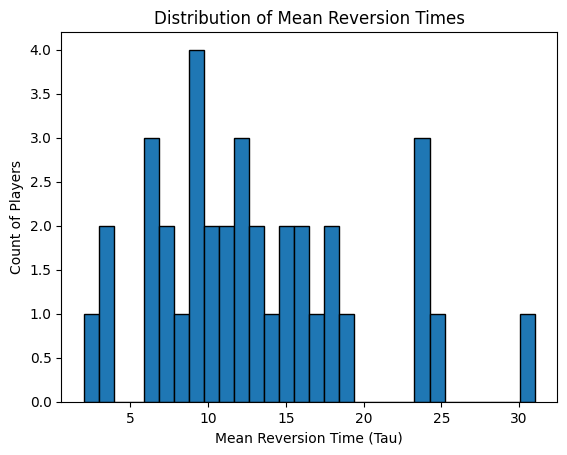

In [37]:
import matplotlib.pyplot as plt

plt.hist(nba.df_player_boxscores[
    nba.df_player_boxscores['PLAYER_NAME']=='Aaron Gordon'
]['PTS'], bins=30, edgecolor='black')
plt.xlabel("Mean Reversion Time (Tau)")
plt.ylabel("Count of Players")
plt.title("Distribution of Mean Reversion Times")
plt.show()



In [33]:
pts_cols = []
for i in nba.df_players.columns:
    if  'line' in i.lower():
        pts_cols.append(i)

#nba.df_players[pts_cols]
pts_cols

['threes_line',
 'stl_line',
 'reb_line',
 'ra_line',
 'pts_line',
 'pra_line',
 'pr_line',
 'pa_line',
 'blk_line',
 'ast_line',
 'sb_line']

# scratch

In [16]:
from nba_api.stats.endpoints import commonallplayers
import pandas as pd

players = commonallplayers.CommonAllPlayers(is_only_current_season=1)

# Convert to DataFrame
cols = {
    'PERSON_ID':'nbaId',
    'DISPLAY_FIRST_LAST':'player',
    'TEAM_ID':'nbaTid'
}
df_players = players.get_data_frames()[0]

df_players = df_players[cols.keys()]
df_players = df_players.rename(columns=cols)

df_players['joinName'] = df_players['player'].apply(hf.apply_regex_replacements)

print(df_players.shape)


(529, 4)


In [12]:
players = commonallplayers.CommonAllPlayers(is_only_current_season=0)
df_players = players.get_data_frames()[0]
df_players.shape

(5103, 16)

In [15]:
df_players[df_players['ROSTERSTATUS']==1]

,PERSON_ID,DISPLAY_LAST_COMMA_FIRST,DISPLAY_FIRST_LAST,ROSTERSTATUS,FROM_YEAR,TO_YEAR,PLAYERCODE,PLAYER_SLUG,TEAM_ID,TEAM_CITY,TEAM_NAME,TEAM_ABBREVIATION,TEAM_CODE,TEAM_SLUG,GAMES_PLAYED_FLAG,OTHERLEAGUE_EXPERIENCE_CH
10,1630173,"Achiuwa, Precious",Precious Achiuwa,1,2020,2025,precious_achiuwa,precious_achiuwa,1610612758,Sacramento,Kings,SAC,kings,kings,Y,00
22,203500,"Adams, Steven",Steven Adams,1,2013,2025,steven_adams,steven_adams,1610612745,Houston,Rockets,HOU,rockets,rockets,Y,00
24,1628389,"Adebayo, Bam",Bam Adebayo,1,2017,2025,bam_adebayo,bam_adebayo,1610612748,Miami,Heat,MIA,heat,heat,Y,00
29,1630534,"Agbaji, Ochai",Ochai Agbaji,1,2022,2025,ochai_agbaji,ochai_agbaji,1610612761,Toronto,Raptors,TOR,raptors,raptors,Y,00
41,1630583,"Aldama, Santi",Santi Aldama,1,2021,2025,santi_aldama,santi_aldama,1610612763,Memphis,Grizzlies,MEM,grizzlies,grizzlies,Y,01
52,1641725,"Alexander, Trey",Trey Alexander,1,2024,2025,trey_alexander,trey_alexander,1610612740,New Orleans,Pelicans,NOP,pelicans,pelicans,Y,01
55,1629638,"Alexander-Walker, Nickeil",Nickeil Alexander-Walker,1,2019,2025,nickeil_alexander-walker,nickeil_alexander-walker,1610612737,Atlanta,Hawks,ATL,hawks,hawks,Y,01
59,1628960,"Allen, Grayson",Grayson Allen,1,2018,2025,grayson_allen,grayson_allen,1610612756,Phoenix,Suns,PHX,suns,suns,Y,01
60,1628386,"Allen, Jarrett",Jarrett Allen,1,2017,2025,jarrett_allen,jarrett_allen,1610612739,Cleveland,Cavaliers,CLE,cavaliers,cavaliers,Y,00
77,1630631,"Alvarado, Jose",Jose Alvarado,1,2021,2025,jose_alvarado,jose_alvarado,1610612740,New Orleans,Pelicans,NOP,pelicans,pelicans,Y,00


96 players added to db..


In [3]:
a

,joinName,nbaId,player_x,actnetId,player_y,player,hooprId
0,kasparas jakucionis,1642857.0,Kasparas Jakučionis,NaN,NaN,NaN,NaN
1,caleb love,1631126.0,Caleb Love,NaN,NaN,Caleb Love,4433144.0
2,john tonje,1642910.0,John Tonje,NaN,NaN,NaN,NaN
3,tyrese proctor,1642878.0,Tyrese Proctor,NaN,NaN,Tyrese Proctor,5023693.0
4,cedric coward,1642907.0,Cedric Coward,307440.0,Cedric Coward,Cedric Coward,4903027.0
5,taelon peter,1643007.0,Taelon Peter,NaN,NaN,Taelon Peter,4703421.0
6,dylan harper,1642844.0,Dylan Harper,307431.0,Dylan Harper,Dylan Harper,5037871.0
7,sion james,1642883.0,Sion James,307464.0,Sion James,Sion James,4602025.0
8,noah penda,1642869.0,Noah Penda,NaN,NaN,Noah Penda,5214637.0
9,chris manon,1643024.0,Chris Mañon,NaN,NaN,Chris Manon,4702972.0


(1073, 8)